<h1 style="text-align:center">   
      <font color = White >
            <span style='font-family:Georgia'>
                Credit Card Fraud Detection: Project 4
            </span>   
        </font>    
</h1>
<h3 style="text-align:CENTER">   
      <font color = white >
            <span style='font-family:Georgia'>
                By : Team 9
            </span>   
        </font>    
</h3>
<hr style="width:100%;height:5px;border-width:0;color:gray;background-color:gray">
<center>

## Import Python Libraries:


In [109]:
# Lets import the required libraries and packages
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from math import radians, cos, sin, asin, sqrt


from sklearn import metrics
from sklearn.metrics import precision_recall_curve, roc_auc_score
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, f1_score
# Plot Style
from matplotlib import style
sns.set_context("paper")
style.use('fivethirtyeight')
sns.set_theme()

## Suppress Warnings:


In [2]:
# Lets Supress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
###TIME counter

import time
start_time = time.time()

### Reading the train dataset 


In [3]:
# Lets import and read the dataset
fraud_train = pd.read_csv("fraudTrain.csv")
fraud_train.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


### Inspect train dataset


In [10]:
# Lets check the info to see the types of the feature variables and the null values present
fraud_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [5]:
# Lets check the summary of the dataset
fraud_train.describe(include='all')

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1296675,1.296675e+06,1296675,1296675,1.296675e+06,1296675,1296675,1296675,1296675,...,1.296675e+06,1.296675e+06,1.296675e+06,1296675,1296675,1296675,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
unique,NaN,1274791,NaN,693,14,NaN,352,481,2,983,...,NaN,NaN,NaN,494,968,1296675,NaN,NaN,NaN,NaN
top,NaN,2019-04-22 16:02:01,NaN,fraud_Kilback LLC,gas_transport,NaN,Christopher,Smith,F,0069 Robin Brooks Apt. 695,...,NaN,NaN,NaN,Film/video editor,1977-03-23,0b242abb623afc578575680df30655b9,NaN,NaN,NaN,NaN
freq,NaN,4,NaN,4403,131659,NaN,26669,28794,709863,3123,...,NaN,NaN,NaN,9779,5636,1,NaN,NaN,NaN,NaN
mean,6.483370e+05,NaN,4.171920e+17,NaN,NaN,7.035104e+01,NaN,NaN,NaN,NaN,...,3.853762e+01,-9.022634e+01,8.882444e+04,NaN,NaN,NaN,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,NaN,1.308806e+18,NaN,NaN,1.603160e+02,NaN,NaN,NaN,NaN,...,5.075808e+00,1.375908e+01,3.019564e+05,NaN,NaN,NaN,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,NaN,6.041621e+10,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,...,2.002710e+01,-1.656723e+02,2.300000e+01,NaN,NaN,NaN,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,NaN,1.800429e+14,NaN,NaN,9.650000e+00,NaN,NaN,NaN,NaN,...,3.462050e+01,-9.679800e+01,7.430000e+02,NaN,NaN,NaN,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,NaN,3.521417e+15,NaN,NaN,4.752000e+01,NaN,NaN,NaN,NaN,...,3.935430e+01,-8.747690e+01,2.456000e+03,NaN,NaN,NaN,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,NaN,4.642255e+15,NaN,NaN,8.314000e+01,NaN,NaN,NaN,NaN,...,4.194040e+01,-8.015800e+01,2.032800e+04,NaN,NaN,NaN,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00


### Duplicate value analysis


In [11]:
# checking duplicates
sum(fraud_train.duplicated(subset = 'cc_num')) == 0

False

In [12]:
# Lets check the dimensions of the dataset
fraud_train.shape

(1296675, 23)

In [13]:
fraud_train.drop_duplicates()
fraud_train.shape

(1296675, 23)

## Data Cleaning 

### Checking Null Values 


In [14]:
# Lets check the null values present in the dataset
fraud_train.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

### Dropping Unnecessary Columns 


In [15]:
# Lets delete unwanted column
fraud_train= fraud_train.drop(['Unnamed: 0'],axis=1)
fraud_train= fraud_train.drop(['first'],axis=1)
fraud_train= fraud_train.drop(['last'],axis=1)

# Lets again check the dimensions of the dataset
fraud_train.shape

(1296675, 20)

In [16]:
# Identifying columns unique value
print(fraud_train.nunique(dropna=False).sort_values())

is_fraud                       2
gender                         2
category                      14
state                         51
job                          494
merchant                     693
city_pop                     879
city                         894
dob                          968
lat                          968
long                         969
zip                          970
street                       983
cc_num                       983
amt                        52928
merch_lat                1247805
trans_date_trans_time    1274791
unix_time                1274823
merch_long               1275745
trans_num                1296675
dtype: int64


### Data Manipulation
        

### Checking the Skewness of following variables `'job', 'category', 'state', 'city'`

In [18]:
df=fraud_train[['job', 'category', 'state', 'city']]

for c in df.columns:
    print ("-----------------------------------------------------" )
    print ("---- %s ---" % c)
    print( df[c].value_counts(normalize=True))

-----------------------------------------------------
---- job ---
job
Film/video editor             0.007542
Exhibition designer           0.007094
Naval architect               0.006697
Surveyor, land/geomatics      0.006694
Materials engineer            0.006378
                                ...   
Information officer           0.000006
Veterinary surgeon            0.000006
Ship broker                   0.000005
Contracting civil engineer    0.000005
Warehouse manager             0.000005
Name: proportion, Length: 494, dtype: float64
-----------------------------------------------------
---- category ---
category
gas_transport     0.101536
grocery_pos       0.095350
home              0.094947
shopping_pos      0.089978
kids_pets         0.087173
shopping_net      0.075225
entertainment     0.072504
food_dining       0.070535
personal_care     0.069993
health_fitness    0.066230
misc_pos          0.061430
misc_net          0.048807
grocery_net       0.035053
travel            0.03

### Binning of `job` column 

In [19]:
fraud_train['job'].describe()

count               1296675
unique                  494
top       Film/video editor
freq                   9779
Name: job, dtype: object

In [20]:
fraud_train['job'][fraud_train['job'].str.contains('(Teacher|teacher|Lecturer|lecturer|Professor|professor)',regex=True)].value_counts()

job
Secondary school teacher                  5609
Early years teacher                       5566
Special educational needs teacher         5099
Teacher, special educational needs        4594
Further education lecturer                4131
English as a second language teacher      4125
Lecturer, further education               3586
Private music teacher                     3561
Lecturer, higher education                2994
Teacher, secondary school                 2549
Teacher, early years/pre                  2487
Teacher, primary school                   1471
Teacher, English as a foreign language    1009
TEFL teacher                               533
Associate Professor                        530
Teacher, adult education                   514
Primary school teacher                     513
Professor Emeritus                         510
English as a foreign language teacher      496
Name: count, dtype: int64

In [21]:
fraud_train['job'].replace(["Secondary school teacher","Early years teacher","TEFL teacher",
        "Special educational needs teacher","Teacher, special educational needs",
        "Further education lecturer","English as a second language teacher","Associate Professor",
        "Lecturer, further education","Private music teacher","Lecturer, higher education",
        "Teacher, early years/pre","Teacher, secondary school","Teacher, primary school",
        "Teacher, English as a foreign language","Primary school teacher","Professor Emeritus",
        "English as a foreign language teacher","Teacher, adult education"],'Teacher', inplace=True)

In [22]:
fraud_train['job'][fraud_train['job'].str.contains('(Engineering|engineering|Engineer|engineer)',
                                                        regex=True)].value_counts()

job
Materials engineer                       8270
Water engineer                           6164
Mining engineer                          6151
Energy engineer                          5668
Petroleum engineer                       5667
Engineer, automotive                     5634
Mechanical engineer                      5632
Electrical engineer                      5179
Drilling engineer                        5132
Engineer, biomedical                     5120
Chemical engineer                        5086
Engineer, production                     4632
Engineer, control and instrumentation    4586
Engineering geologist                    4088
Engineer, electronics                    3612
Engineer, mining                         3595
Structural engineer                      3558
Geologist, engineering                   3120
Site engineer                            3090
Electronics engineer                     3087
Manufacturing engineer                   3058
Engineer, land                

In [23]:
fraud_train['job'].replace(["Materials engineer","Mining engineer","Water engineer","Engineer, land",
        "Mechanical engineer","Engineer, automotive","Petroleum engineer","Energy engineer",
        "Chemical engineer","Engineer, biomedical","Drilling engineer","Electrical engineer",
        "Engineer, production","Engineer, control and instrumentation","Engineering geologist",
        "Structural engineer","Engineer, mining","Engineer, electronics","Site engineer",
        "Geologist, engineering","Electronics engineer","Manufacturing engineer","Engineer, site",
        "Maintenance engineer","Engineer, petroleum","Communications engineer","Network engineer",
        "Civil engineer, contracting","Engineer, technical sales","Biomedical engineer",
        "Engineer, drilling","Aeronautical engineer","Production engineer","Engineer, maintenance",
        "Engineer, agricultural","Engineer, civil (contracting)","Engineer, communications",
        "Building services engineer","Control and instrumentation engineer","Engineer, structural",
        "Engineer, building services","Manufacturing systems engineer","Engineer, aeronautical",
        "Engineer, broadcasting (operations)","Engineer, manufacturing","Broadcast engineer",
        "Engineer, civil (consulting)","Engineer, materials","Software engineer","Engineer, water",
        'Contracting civil engineer'], 'Engineer', inplace=True)

In [24]:
fraud_train['job'].value_counts()

job
Engineer                          138964
Teacher                            49877
Film/video editor                   9779
Exhibition designer                 9199
Naval architect                     8684
                                   ...  
Veterinary surgeon                     8
Information officer                    8
Armed forces technical officer         8
Ship broker                            7
Warehouse manager                      7
Name: count, Length: 428, dtype: int64

In [25]:
fraud_train['job'][fraud_train['job'].str.contains('(Scientist|scientist)',
                                                                        regex=True)].value_counts()

job
Scientist, audiological                                        7174
Scientist, research (maths)                                    6159
Audiological scientist                                         6118
Geoscientist                                                   5620
Research scientist (physical sciences)                         5185
Scientist, marine                                              5089
Scientist, biomedical                                          4130
Biomedical scientist                                           3080
Product/process development scientist                          3030
Soil scientist                                                 2579
Scientist, physiological                                       2087
Scientist, research (physical sciences)                        2043
Research scientist (life sciences)                             2030
Research scientist (maths)                                     1543
Physiological scientist                     

In [26]:
fraud_train['job'].replace(["Scientist, audiological","Audiological scientist","Data scientist",
            "Scientist, research (maths)","Geoscientist","Research scientist (physical sciences)",
            "Scientist, marine","Scientist, biomedical","Biomedical scientist",
            "Product/process development scientist","Soil scientist","Scientist, physiological",
            "Research scientist (life sciences)","Scientist, research (physical sciences)",
            "Physiological scientist","Research scientist (maths)","Research scientist (medical)",
            "Scientist, research (medical)","Water quality scientist",
            "Scientist, clinical (histocompatibility and immunogenetics)"],'Scientist', inplace=True)

In [27]:
fraud_train['job'][fraud_train['job'].str.contains('(Officer|officer)',regex=True)].value_counts()

job
Chief Executive Officer                                  7172
Historic buildings inspector/conservation officer        6205
Prison officer                                           5701
Trading standards officer                                4641
Chief Strategy Officer                                   4603
Race relations officer                                   4591
Exhibitions officer, museum/gallery                      4144
Probation officer                                        4112
Fisheries officer                                        3617
Research officer, political party                        3613
Research officer, trade union                            3564
Education officer, museum                                3100
Regulatory affairs officer                               3085
Chief Operating Officer                                  3043
Careers information officer                              2961
Chief Technology Officer                                 2580
Tour

In [28]:
fraud_train['job'].replace(['Chief Executive Officer','Armed forces technical officer',
            'Personnel officer','Information officer','Local government officer',"Police officer",
            'Public relations officer','Education officer, community',"Tourism officer",
            'Field trials officer','Charity officer','Nature conservation officer',
            'Environmental education officer',"Environmental education officer",
            "Museum education officer","Medical technical officer","Chief Operating Officer",
           'Race relations officer','Prison officer','Chief Strategy Officer',"Immigration officer", 
            'Probation officer','Exhibitions officer, museum/gallery','Fisheries officer',     
            'Research officer, trade union ','Research officer, political party',   
            "Historic buildings inspector/conservation officer","Trading standards officer",
            "Careers information officer","Regulatory affairs officer","Human resources officer",
            "Armed forces training and education officer","Chief Technology Officer",
            "Chief Financial Officer","Equality and diversity officer","Waste management officer",
            "Chief Marketing Officer","Museum/gallery exhibitions officer",
            "Sports development officer","Arts development officer","Community education officer",
     "Emergency planning/management officer","Armed forces logistics/support/administrative officer",
           "Conservation officer, historic buildings","Training and development officer",
            "Social research officer, government",'Education officer, museum'],
                          'Officer', inplace=True)

In [29]:
fraud_train['job'].value_counts(normalize=True)

job
Engineer                   0.107169
Officer                    0.082789
Scientist                  0.047427
Teacher                    0.038465
Film/video editor          0.007542
                             ...   
Broadcast journalist       0.000007
Forest/woodland manager    0.000007
Veterinary surgeon         0.000006
Ship broker                0.000005
Warehouse manager          0.000005
Name: proportion, Length: 365, dtype: float64

In [30]:
fraud_train['job'][fraud_train['job'].str.contains('(Surveyor|surveyor)',regex=True)].value_counts()

job
Surveyor, land/geomatics             8680
Building surveyor                    6178
Quantity surveyor                    5646
Land/geomatics surveyor              5604
Surveyor, minerals                   4552
Insurance risk surveyor              3603
Commercial/residential surveyor      2965
Building control surveyor            2561
Surveyor, rural practice             2524
Planning and development surveyor    1572
Surveyor, mining                     1554
Rural practice surveyor              1519
Hydrographic surveyor                1041
Surveyor, hydrographic                533
Minerals surveyor                     530
Name: count, dtype: int64

In [31]:
fraud_train['job'].replace(["Surveyor, land/geomatics","Building surveyor","Quantity surveyor",
            "Land/geomatics surveyor","Surveyor, minerals","Insurance risk surveyor",
            "Commercial/residential surveyor","Building control surveyor","Surveyor, rural practice",
            "Planning and development surveyor","Surveyor, mining","Rural practice surveyor",
            "Hydrographic surveyor","Minerals surveyor","Surveyor, hydrographic"],
                          'Surveyor', inplace=True)

In [32]:
fraud_train['job'][fraud_train['job'].str.contains('(Designer|designer)',regex=True)].value_counts()

job
Exhibition designer              9199
Designer, ceramics/pottery       8225
Ceramics designer                4493
Designer, industrial/product     4129
Designer, jewellery              3083
Designer, furniture              3064
Designer, exhibition/display     3026
Web designer                     2556
Product designer                 2545
Industrial/product designer      2077
Glass blower/designer            2072
Furniture designer               2043
Designer, interior/spatial       1562
Set designer                     1545
Designer, multimedia             1053
Designer, textile                1045
Jewellery designer               1011
Designer, television/film set     534
Textile designer                  519
Interior and spatial designer     509
Name: count, dtype: int64

In [33]:
fraud_train['job'].replace(["Exhibition designer","Designer, ceramics/pottery","Ceramics designer",
            "Designer, industrial/product","Designer, jewellery","Designer, exhibition/display",
            "Designer, furniture","Web designer","Product designer","Glass blower/designer",
            "Furniture designer","Industrial/product designer","Set designer","Designer, textile",
            "Designer, interior/spatial","Jewellery designer","Designer, multimedia",
            "Designer, television/film set","Interior and spatial designer","Textile designer"],
                          'Designer', inplace=True)

In [34]:
fraud_train['job'][fraud_train['job'].str.contains('(manager|Manager)',regex=True)].value_counts()

job
Facilities manager                      3974
Call centre manager                     3581
Heritage manager                        3566
Travel agency manager                   3557
Television floor manager                3130
Tourist information centre manager      3086
Leisure centre manager                  3080
Production manager                      3067
Energy manager                          2918
Health service manager                  2559
Fitness centre manager                  2559
Pension scheme manager                  2088
Public house manager                    2038
Farm manager                            2032
Information systems manager             2021
Theme park manager                      1999
Theatre manager                         1555
Logistics and distribution manager      1549
Quarry manager                          1519
Records manager                         1517
Location manager                        1497
Stage manager                           1041
Retail

In [35]:
fraud_train['job'].replace(["Facilities manager","Travel agency manager","Call centre manager",
            "Heritage manager","Production manager","Energy manager","Television floor manager",
            "Leisure centre manager","Tourist information centre manager","Farm manager",
            "Fitness centre manager","Health service manager","Information systems manager",
            "Theme park manager","Pension scheme manager","Public house manager","Quarry manager",
            "Records manager","Logistics and distribution manager","Location manager",
            "Theatre manager","Retail manager","Art gallery manager","Stage manager","Tour manager",
            "Outdoor activities/education manager","Product manager","Hotel manager",
            "Restaurant manager, fast food","Purchasing manager","Catering manager",
            "Environmental manager","Estate manager/land agent","Forest/woodland manager",
                           "Warehouse manager"],'Manager', inplace=True)

In [39]:
fraud_train['job'].value_counts()

job
Engineer                 138964
Officer                  107351
Manager                   61662
Scientist                 61498
Designer                  54290
                          ...  
Accountant, chartered        11
Industrial buyer             10
Broadcast journalist          9
Veterinary surgeon            8
Ship broker                   7
Name: count, Length: 298, dtype: int64

In [40]:
fraud_train['job'][fraud_train['job'].str.contains('(psychologist|Psychologist)',regex=True)].value_counts()

job
Psychologist, forensic              5476
Counselling psychologist            4649
Educational psychologist            4517
Occupational psychologist           4079
Forensic psychologist               3617
Psychologist, counselling           3545
Psychologist, sport and exercise    2086
Sport and exercise psychologist     2065
Psychologist, clinical              1559
Clinical psychologist               1007
Name: count, dtype: int64

In [41]:
fraud_train['job'].replace(["Psychologist, forensic","Counselling psychologist",
            "Educational psychologist","Occupational psychologist","Forensic psychologist",
            "Psychologist, counselling","Sport and exercise psychologist",
            "Psychologist, sport and exercise","Psychologist, clinical","Clinical psychologist"],
                          'Psychologist', inplace=True)

In [42]:
fraud_train['job'][fraud_train['job'].str.contains('(editor|Editor)',regex=True)].value_counts()

job
Film/video editor            9779
Magazine features editor     6602
Editor, commissioning        3633
Video editor                 3085
Editor, film/video           2063
Editor, magazine features    2041
Commissioning editor         1522
Name: count, dtype: int64

In [43]:
fraud_train['job'].replace(["Film/video editor","Magazine features editor","Editor, commissioning",
                    "Video editor","Editor, film/video","Editor, magazine features",
                    "Commissioning editor"],'Editor', inplace=True)

In [44]:
fraud_train['job'][fraud_train['job'].str.contains('(Producer|producer)',regex=True)].value_counts()

job
Radio producer                     4606
Television/film/video producer     4136
Producer, radio                    3111
Producer, television/film/video     493
Name: count, dtype: int64

In [45]:
fraud_train['job'].replace(['Radio producer','Television/film/video producer',
                'Producer, television/film/video','Producer, radio'],'Producer', inplace=True)

In [46]:
fraud_train['job'][fraud_train['job'].str.contains('(therapist|Therapist)',regex=True)].value_counts()

job
Psychotherapist, child            5460
Physiotherapist                   4602
Therapist, occupational           4576
Child psychotherapist             4095
Phytotherapist                    3100
Therapist, sports                 2564
Music therapist                   2562
Therapist, art                    2554
Therapist, horticultural          2528
Horticultural therapist           2094
Nutritional therapist             2060
Therapist, drama                  2056
Art therapist                     2055
Psychotherapist                   2048
Dance movement psychotherapist    2017
Therapist, music                  1542
Occupational therapist             519
Name: count, dtype: int64

In [47]:
fraud_train['job'].replace(["Psychotherapist, child","Therapist, occupational","Physiotherapist",
                "Child psychotherapist","Phytotherapist","Therapist, horticultural","Therapist, art",
                "Therapist, sports","Music therapist","Horticultural therapist","Art therapist",
                "Nutritional therapist","Dance movement psychotherapist","Psychotherapist",
                "Therapist, drama","Therapist, music","Occupational therapist"],
                          'Therapist', inplace=True)

In [48]:
fraud_train['job'][fraud_train['job'].str.contains('(nurse|Nurse)',regex=True)].value_counts()

job
Learning disability nurse    3575
Nurse, children's            2589
Mental health nurse          2557
Paediatric nurse             2545
Psychiatric nurse            1553
Nurse, mental health         1015
Name: count, dtype: int64

In [49]:
fraud_train['job'].replace(["Learning disability nurse","Nurse, children's","Paediatric nurse",
                    "Mental health nurse","Psychiatric nurse","Nurse, mental health"],
                          'Nurse', inplace=True)

In [51]:
fraud_train['job'].value_counts()

job
Engineer                138964
Officer                 107351
Manager                  61662
Scientist                61498
Designer                 54290
                         ...  
Solicitor                   11
Industrial buyer            10
Broadcast journalist         9
Veterinary surgeon           8
Ship broker                  7
Name: count, Length: 259, dtype: int64

In [52]:
fraud_train['job'][fraud_train['job'].str.contains('(assistant|Assistant)',regex=True)].value_counts()

job
Television production assistant     5118
Radio broadcast assistant           4583
Politician's assistant              2067
Production assistant, radio         1031
Production assistant, television     531
Name: count, dtype: int64

In [53]:
fraud_train['job'].replace(["Television production assistant","Radio broadcast assistant",
                    "Politician's assistant","Production assistant, radio",
                    "Production assistant, television"], 'Assistant', inplace=True)

In [54]:
fraud_train['job'][fraud_train['job'].str.contains('(executive|Executive)',regex=True)].value_counts()

job
Public relations account executive               4033
Advertising account executive                    1573
Sales executive                                  1554
Chartered legal executive (England and Wales)    1023
Marketing executive                               508
Sales promotion account executive                  14
Name: count, dtype: int64

In [55]:
fraud_train['job'].replace(["Public relations account executive","Advertising account executive",
                    "Sales executive","Chartered legal executive (England and Wales)",
                    "Marketing executive","Sales promotion account executive"],
                          'Executive', inplace=True)

In [56]:
fraud_train['job'][fraud_train['job'].str.contains('(librarian|Librarian)',regex=True)].value_counts()

job
Librarian, public      6186
Librarian, academic    5203
Public librarian       1527
Academic librarian     1041
Name: count, dtype: int64

In [57]:
fraud_train['job'].replace(["Librarian, public","Librarian, academic","Public librarian",
                           "Academic librarian"], 'Librarian', inplace=True)

In [58]:
fraud_train['job'][fraud_train['job'].str.contains('(researcher|Researcher)',regex=True)].value_counts()

job
Social researcher                                4609
Programme researcher, broadcasting/film/video    4150
Market researcher                                2596
Operational researcher                           2566
Telecommunications researcher                    2080
Name: count, dtype: int64

In [59]:
fraud_train['job'].replace(["Social researcher","Programme researcher, broadcasting/film/video",
                    "Market researcher","Operational researcher","Telecommunications researcher"],
                          'Researcher', inplace=True)

In [60]:
fraud_train['job'][fraud_train['job'].str.contains('(consultant|Consultant)',regex=True)].value_counts()

job
Environmental consultant     7547
Agricultural consultant      6642
Pensions consultant          5504
Public affairs consultant    2024
Management consultant        1531
IT consultant                1004
Horticultural consultant      533
Name: count, dtype: int64

In [61]:
fraud_train['job'].replace(["Environmental consultant","Agricultural consultant","IT consultant",
                    "Pensions consultant","Public affairs consultant","Management consultant",
                    "Horticultural consultant"], 'Consultant', inplace=True)

In [62]:
fraud_train['job'][fraud_train['job'].str.contains('(conservator|Conservator)',regex=True)].value_counts()

job
Museum/gallery conservator        2072
Furniture conservator/restorer    1049
Conservator, furniture             536
Conservator, museum/gallery        514
Name: count, dtype: int64

In [63]:
fraud_train['job'].replace(["Museum/gallery conservator","Furniture conservator/restorer",
                "Conservator, museum/gallery","Conservator, furniture"], 'Conservator', inplace=True)

In [64]:
fraud_train['job'][fraud_train['job'].str.contains('(banker|Banker)',regex=True)].value_counts()

job
Retail banker                     2046
Investment banker, corporate      2029
Corporate investment banker       2023
Investment banker, operational     510
Name: count, dtype: int64

In [65]:
fraud_train['job'].replace(["Investment banker, corporate","Corporate investment banker",
                "Retail banker","Investment banker, operational","Operational investment banker"], 
                'Banker', inplace=True)

In [66]:
fraud_train['job'][fraud_train['job'].str.contains('(chemist|Chemist)',regex=True)].value_counts()

job
Geochemist              2530
Clinical biochemist     2063
Biochemist, clinical    1038
Chemist, analytical     1012
Analytical chemist       499
Name: count, dtype: int64

In [67]:
fraud_train['job'].replace(["Geochemist","Clinical biochemist","Biochemist, clinical",
                    "Chemist, analytical","Analytical chemist"], 'Chemist', inplace=True)

In [68]:
fraud_train['job'][fraud_train['job'].str.contains('(Accountant|accountant)',regex=True)].value_counts()

job
Chartered public finance accountant     7210
Accountant, chartered public finance    2580
Chartered accountant                    1502
Accountant, chartered certified          534
Accountant, chartered                     11
Name: count, dtype: int64

In [69]:
fraud_train['job'].replace(["Chartered public finance accountant","Chartered accountant",
                    "Accountant, chartered public finance","Accountant, chartered certified",
                    "Accountant, chartered"], 'Chartered Accountant', inplace=True)

In [70]:
fraud_train['job'][fraud_train['job'].str.contains('(administrator|Administrator)',regex=True)].value_counts()

job
Administrator                                       3604
Administrator, local government                     2605
Administrator, education                            2571
Database administrator                              2560
Administrator, charities/voluntary organisations    2524
Secretary/administrator                             2054
Sports administrator                                1055
Education administrator                             1028
Administrator, arts                                  535
Civil Service administrator                          506
Name: count, dtype: int64

In [71]:
fraud_train['job'].replace(["Administrator","Administrator, local government",
                "Administrator, education","Administrator, charities/voluntary organisations",
                "Database administrator","Secretary/administrator","Sports administrator",
                "Education administrator","Civil Service administrator","Administrator, arts"], 
                          'Administrator', inplace=True)

In [72]:
fraud_train['job'][fraud_train['job'].str.contains('(Writer|writer)',regex=True)].value_counts()

job
Copywriter, advertising    7146
Insurance underwriter      5170
Science writer             5161
Advertising copywriter     1031
Writer                      504
Name: count, dtype: int64

In [73]:
fraud_train['job'].replace(["Copywriter, advertising","Science writer","Insurance underwriter",
                    "Advertising copywriter","Writer"], 'Writer', inplace=True)

In [74]:
fraud_train['job'].value_counts()

job
Engineer                138964
Officer                 107351
Manager                  61662
Scientist                61498
Designer                 54290
                         ...  
Solicitor                   11
Industrial buyer            10
Broadcast journalist         9
Veterinary surgeon           8
Ship broker                  7
Name: count, Length: 210, dtype: int64

In [75]:
fraud_train['job'][fraud_train['job'].str.contains('(Doctor|doctor|Surgeon|surgeon)',regex=True)].value_counts()

job
Surgeon                     4138
Hospital doctor             3573
Tree surgeon                3142
Doctor, general practice    2582
Doctor, hospital            2554
Neurosurgeon                2101
General practice doctor     2001
Veterinary surgeon             8
Name: count, dtype: int64

In [76]:
fraud_train['job'].replace(["Surgeon","Hospital doctor","Doctor, general practice","Doctor, hospital",
                "Tree surgeon","Neurosurgeon","Veterinary surgeon","General practice doctor"], 
                          'Doctor', inplace=True)

In [77]:
fraud_train['job'][fraud_train['job'].str.contains('(buyer|Buyer)',regex=True)].value_counts()

job
Buyer, industrial    4102
Media buyer          2561
Retail buyer         2089
Buyer, retail         496
Industrial buyer       10
Name: count, dtype: int64

In [78]:
fraud_train['job'].replace(["Buyer, industrial","Media buyer","Retail buyer","Buyer, retail","Industrial buyer"], 
                                                                                  'Buyer', inplace=True)

In [79]:
fraud_train['job'][fraud_train['job'].str.contains('(Geneticist|geneticist)',regex=True)].value_counts()

job
Cytogeneticist              5088
Plant breeder/geneticist    1060
Geneticist, molecular        545
Clinical cytogeneticist      508
Name: count, dtype: int64

In [80]:
fraud_train['job'].replace(["Cytogeneticist","Plant breeder/geneticist","Geneticist, molecular",
                        "Clinical cytogeneticist"], 'Geneticist', inplace=True)

In [81]:
fraud_train['job'][fraud_train['job'].str.contains('(pharmacist|Pharmacist)',regex=True)].value_counts()

job
Pharmacist, community    2024
Community pharmacist     1551
Pharmacist, hospital     1059
Hospital pharmacist      1039
Name: count, dtype: int64

In [82]:
fraud_train['job'].replace(["Pharmacist, community","Community pharmacist","Pharmacist, hospital",
                           "Hospital pharmacist"], 'Pharmacist', inplace=True)

In [83]:
fraud_train['job'][fraud_train['job'].str.contains('(physicist|Physicist)',regex=True)].value_counts()

job
Physicist, medical                 3580
Health physicist                   3034
Medical physicist                  1578
Geophysicist/field seismologist    1521
Name: count, dtype: int64

In [84]:
fraud_train['job'].replace(["Physicist, medical","Health physicist","Medical physicist",
                           "Geophysicist/field seismologist"], 'Physicist', inplace=True)

In [85]:
fraud_train['job'][fraud_train['job'].str.contains('(analyst|Analyst)',regex=True)].value_counts()

job
Systems analyst         3595
Risk analyst            2595
Investment analyst      2530
Intelligence analyst    2498
Name: count, dtype: int64

In [86]:
fraud_train['job'].replace(["Systems analyst","Risk analyst","Investment analyst","Intelligence analyst"], 
                                                                          'Analyst', inplace=True)

In [87]:
fraud_train['job'][fraud_train['job'].str.contains('(technologist|Technologist)',regex=True)].value_counts()

job
Clothing/textile technologist    6049
Colour technologist              3526
Animal technologist              2044
Garment/textile technologist     1535
Architectural technologist       1024
Name: count, dtype: int64

In [88]:
fraud_train['job'].replace(["Clothing/textile technologist","Colour technologist","Animal technologist",
                "Garment/textile technologist","Architectural technologist"], 'Technologist', inplace=True)

In [89]:
fraud_train['job'][fraud_train['job'].str.contains('(technician|Technician)',regex=True)].value_counts()

job
Accounting technician               4673
Scientific laboratory technician    2030
Teaching laboratory technician      1506
Name: count, dtype: int64

In [90]:
fraud_train['job'].replace(["Accounting technician","Scientific laboratory technician",
                           "Teaching laboratory technician"], 'Technician', inplace=True)

In [91]:
fraud_train['job'][fraud_train['job'].str.contains('(horticulturist|Horticulturist)',regex=True)].value_counts()

job
Amenity horticulturist        3545
Commercial horticulturist     3050
Horticulturist, commercial    2034
Name: count, dtype: int64

In [92]:
fraud_train['job'].replace(['Amenity horticulturist','Commercial horticulturist','Horticulturist, commercial'], 
                                                                      'Horticulturist', inplace=True)

fraud_train['job'].replace(['Retail merchandiser','Merchandiser, retail','Visual merchandiser'], 
                                                                      'Merchandiser', inplace=True)

fraud_train['job'].replace(['Cabin crew','Air cabin crew'],'Cabin crew', inplace=True)

In [93]:
fraud_train['job'].value_counts()

job
Engineer                138964
Officer                 107351
Manager                  61662
Scientist                61498
Designer                 54290
                         ...  
Legal secretary             12
Homeopath                   11
Solicitor                   11
Broadcast journalist         9
Ship broker                  7
Name: count, Length: 176, dtype: int64

In [94]:
job_freqs = fraud_train.job.value_counts()

In [95]:
job_freqs.cumsum()

job
Engineer                 138964
Officer                  246315
Manager                  307977
Scientist                369475
Designer                 423765
                         ...   
Legal secretary         1296637
Homeopath               1296648
Solicitor               1296659
Broadcast journalist    1296668
Ship broker             1296675
Name: count, Length: 176, dtype: int64

### Lets see the unique values which explains variable `job`

In [99]:
top_jobs = job_freqs.cumsum()[:91].index
top_jobs

Index(['Engineer', 'Officer', 'Manager', 'Scientist', 'Designer', 'Teacher',
       'Surveyor', 'Therapist', 'Psychologist', 'Editor', 'Consultant',
       'Doctor', 'Administrator', 'Writer', 'Researcher', 'Technologist',
       'Librarian', 'Nurse', 'Assistant', 'Producer', 'Chartered Accountant',
       'Analyst', 'Physicist', 'Buyer', 'Executive', 'Naval architect',
       'Horticulturist', 'Technician', 'Systems developer', 'IT trainer',
       'Financial adviser', 'Geneticist', 'Chemist', 'Comptroller', 'Sub',
       'Podiatrist', 'Paramedic', 'Banker', 'Musician', 'Barrister',
       'Immunologist', 'Financial trader', 'Pharmacist',
       'Claims inspector/assessor', 'Make', 'Counsellor', 'Firefighter',
       'Sales professional, IT', 'Medical sales representative',
       'Chartered loss adjuster', 'Merchandiser', 'Trade mark attorney',
       'Multimedia programmer', 'Dealer', 'Technical brewer', 'Toxicologist',
       'Fine artist', 'Conservator', 'Advertising account plann

In [100]:
fraud_train['job'].value_counts()

job
Engineer                138964
Officer                 107351
Manager                  61662
Scientist                61498
Designer                 54290
                         ...  
Legal secretary             12
Homeopath                   11
Solicitor                   11
Broadcast journalist         9
Ship broker                  7
Name: count, Length: 176, dtype: int64

In [101]:
fraud_train['job'].describe()

count      1296675
unique         176
top       Engineer
freq        138964
Name: job, dtype: object

In [102]:
fraud_train.shape

(1296675, 20)

## Feature Engineering


### Deriving `age` on transaction day from "dob" variable and binning of age variable

In [107]:
fraud_train['dob'] = pd.to_datetime(fraud_train['dob'])


fraud_train["age"] = fraud_train["dob"].apply(lambda x: (pd.to_datetime('now').year - x.year))


In [108]:
fraud_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 21 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  object        
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  object        
 3   category               1296675 non-null  object        
 4   amt                    1296675 non-null  float64       
 5   gender                 1296675 non-null  object        
 6   street                 1296675 non-null  object        
 7   city                   1296675 non-null  object        
 8   state                  1296675 non-null  object        
 9   zip                    1296675 non-null  int64         
 10  lat                    1296675 non-null  float64       
 11  long                   1296675 non-null  float64       
 12  city_pop               12966

###  Deriving `trans_Year`, `trans_year_month`, `trans_Month`, `trans_Hour`, `trans_Day`, `trans_weekday` of transaction from trans_date_trans_time variable

### Deriving `dis` i.e. distance between credit card lat, long to merchant lat and long

In [111]:
 
def haversine_distance(lat, long, merch_lat, merch_long): 
      
    # The math module contains a function named 
    # radians which converts from degrees to radians. 
    long = np.radians(long) 
    merch_long = np.radians(merch_long) 
    lat = np.radians(lat) 
    merch_lat = np.radians(merch_lat) 
       
    # Haversine formula  
    dlon = merch_long - long  
    dlat = merch_lat - lat
    a = np.sin(dlat / 2)**2 + np.cos(lat) * np.cos(merch_lat) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)) 
    #c = 2 * np.arctan2(a**0.5, (1-a)**0.5)
    
    # Radius of earth in kilometers.  
    r = 6371
    d=  c * r
    # calculate the result 
    return round(d,2)

In [112]:
fraud_train['dist']=fraud_train[['lat', 'long', 'merch_lat', 'merch_long']].apply(
                                        lambda x:haversine_distance(x[0], x[1], x[2], x[3]), axis=1)

In [113]:
fraud_train

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,age,dist
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,...,3495,Psychologist,1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,36,78.60
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,...,149,Teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,46,30.21
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,...,4154,Officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,62,108.21
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,...,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,57,95.67
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,...,99,Therapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,38,77.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,M,162 Jessica Row Apt. 072,Hatch,UT,84735,...,258,Scientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0,63,119.75
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,M,8617 Holmes Terrace Suite 651,Tuscarora,MD,21790,...,100,Assistant,1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0,45,75.10
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,NM,88325,...,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0,57,99.05
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,42933 Ryan Underpass,Manderson,SD,57756,...,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0,44,84.63


### Deriving `prev_merch_lat`, `prev_merch_long` i.e Previous longitude/latitude of merchant and `time_since_prev_transaction` i.e time since previous transaction in hours

In [114]:
grp_by_cc = fraud_train.groupby(['cc_num'])

In [121]:
# Get previous longitude/latitude and time elapsed of a transaction
fraud_train['prev_merch_lat']=grp_by_cc['merch_lat'].transform(lambda x:x.shift(1)).fillna(
                                                                        fraud_train['merch_lat'])
fraud_train['prev_merch_long']=grp_by_cc['merch_long'].transform(lambda x:x.shift(1)).fillna(
                                                                        fraud_train['merch_long'])


In [122]:
fraud_train

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,age,dist,prev_merch_lat,prev_merch_long
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,...,1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,36,78.60,36.011293,-82.048315
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,...,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,46,30.21,49.159047,-118.186462
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,...,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,62,108.21,43.150704,-112.154481
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,...,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,57,95.67,47.034331,-112.561071
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,...,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,38,77.56,38.674999,-78.632459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,M,162 Jessica Row Apt. 072,Hatch,UT,84735,...,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0,63,119.75,37.840884,-111.532270
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,M,8617 Holmes Terrace Suite 651,Tuscarora,MD,21790,...,1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0,45,75.10,39.643713,-77.688164
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,NM,88325,...,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0,57,99.05,32.587787,-106.579108
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,42933 Ryan Underpass,Manderson,SD,57756,...,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0,44,84.63,43.249002,-101.919949


### Deriving `distance_between_merchants` by calculating distance between current and previous purchase location

In [123]:
fraud_train['distance_between_merchants']=fraud_train.apply(lambda x:haversine_distance(
                                            x.prev_merch_lat,x.prev_merch_long,x.merch_lat,x.merch_long), axis=1)

In [124]:
fraud_train

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,trans_num,unix_time,merch_lat,merch_long,is_fraud,age,dist,prev_merch_lat,prev_merch_long,distance_between_merchants
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,...,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,36,78.60,36.011293,-82.048315,0.00
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,...,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,46,30.21,49.159047,-118.186462,0.00
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,...,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,62,108.21,43.150704,-112.154481,0.00
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,...,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,57,95.67,47.034331,-112.561071,0.00
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,...,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,38,77.56,38.674999,-78.632459,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,M,162 Jessica Row Apt. 072,Hatch,UT,84735,...,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0,63,119.75,37.840884,-111.532270,112.03
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,M,8617 Holmes Terrace Suite 651,Tuscarora,MD,21790,...,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0,45,75.10,39.643713,-77.688164,94.99
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,NM,88325,...,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0,57,99.05,32.587787,-106.579108,177.10
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,42933 Ryan Underpass,Manderson,SD,57756,...,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0,44,84.63,43.249002,-101.919949,118.97


### Checking the correlations between the variables


In [125]:
# lets check the correlation amongst the features
# Select only the numeric columns
numeric_cols = fraud_train.select_dtypes(include=[np.number])

# Compute the correlation matrix
cor = numeric_cols.corr()

# Display the correlation matrix
print(cor)


                              cc_num       amt       zip       lat      long  \
cc_num                      1.000000  0.001769  0.041459 -0.059271 -0.048278   
amt                         0.001769  1.000000  0.001843 -0.001926 -0.000187   
zip                         0.041459  0.001843  1.000000 -0.114290 -0.909732   
lat                        -0.059271 -0.001926 -0.114290  1.000000 -0.015533   
long                       -0.048278 -0.000187 -0.909732 -0.015533  1.000000   
city_pop                   -0.008991  0.005818  0.078467 -0.155730 -0.052715   
unix_time                   0.000354 -0.000293  0.000670  0.000632 -0.000642   
merch_lat                  -0.058942 -0.001873 -0.113561  0.993592 -0.015452   
merch_long                 -0.048252 -0.000151 -0.908924 -0.015509  0.999120   
is_fraud                   -0.000981  0.219404 -0.002162  0.001894  0.001721   
age                        -0.000291 -0.009748  0.011004  0.047845 -0.030231   
dist                        0.003730 -0.

### Dropping the variables who have high correlation values


In [126]:
fraud_train= fraud_train.drop(['prev_merch_lat','prev_merch_long','merch_lat','merch_long','zip'],axis=1)
fraud_train= fraud_train.drop(['trans_date_trans_time','dob'],axis=1)

fraud_train.shape

(1296675, 18)

In [127]:
fraud_train.columns

Index(['cc_num', 'merchant', 'category', 'amt', 'gender', 'street', 'city',
       'state', 'lat', 'long', 'city_pop', 'job', 'trans_num', 'unix_time',
       'is_fraud', 'age', 'dist', 'distance_between_merchants'],
      dtype='object')

In [128]:
fraud_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 18 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   cc_num                      1296675 non-null  int64  
 1   merchant                    1296675 non-null  object 
 2   category                    1296675 non-null  object 
 3   amt                         1296675 non-null  float64
 4   gender                      1296675 non-null  object 
 5   street                      1296675 non-null  object 
 6   city                        1296675 non-null  object 
 7   state                       1296675 non-null  object 
 8   lat                         1296675 non-null  float64
 9   long                        1296675 non-null  float64
 10  city_pop                    1296675 non-null  int64  
 11  job                         1296675 non-null  object 
 12  trans_num                   1296675 non-null  object 
 1

### Label encoding


In [129]:
from sklearn.preprocessing import LabelEncoder
def preprocess_data(X):
# Convert categorical columns if any
    label_encoders = {}
    for col in X.columns:
        if X[col].dtype == 'object':
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col])
            label_encoders[col] = le
    
    return X, label_encoders

# Preprocess the data
X_train_preprocessed, label_encoders = preprocess_data(fraud_train)

In [130]:
X_train_preprocessed

,cc_num,merchant,category,amt,gender,street,city,state,lat,long,city_pop,job,trans_num,unix_time,is_fraud,age,dist,distance_between_merchants
0,2703186189652095,514,8,4.97,0,568,526,27,36.0788,-81.1781,3495,142,56438,1325376018,0,36,78.60,0.00
1,630423337322,241,4,107.23,0,435,612,47,48.8878,-118.2105,149,161,159395,1325376044,0,46,30.21,0.00
2,38859492057661,390,0,220.11,1,602,468,13,42.1808,-112.2620,4154,120,818703,1325376051,0,62,108.21,0.00
3,3534093764340240,360,2,45.00,1,930,84,26,46.2306,-112.1138,1939,128,544575,1325376076,0,57,95.67,0.00
4,375534208663984,297,9,41.96,1,418,216,45,38.4207,-79.4629,99,167,831111,1325376186,0,38,77.56,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,30263540414123,499,0,15.56,1,154,330,44,37.7175,-112.4777,258,148,344658,1371816728,0,63,119.75,112.03
1296671,6011149206456997,2,1,51.70,1,856,813,20,39.2667,-77.5101,100,18,199896,1371816739,0,45,75.10,94.99
1296672,3514865930894695,599,1,105.93,1,158,346,32,32.9396,-105.8189,899,116,366013,1371816752,0,57,99.05,177.10
1296673,2720012583106919,509,1,74.90,1,433,471,41,43.3526,-102.5411,1126,172,1086299,1371816816,0,44,84.63,118.97


In [131]:
fraud_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 18 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   cc_num                      1296675 non-null  int64  
 1   merchant                    1296675 non-null  int64  
 2   category                    1296675 non-null  int64  
 3   amt                         1296675 non-null  float64
 4   gender                      1296675 non-null  int64  
 5   street                      1296675 non-null  int64  
 6   city                        1296675 non-null  int64  
 7   state                       1296675 non-null  int64  
 8   lat                         1296675 non-null  float64
 9   long                        1296675 non-null  float64
 10  city_pop                    1296675 non-null  int64  
 11  job                         1296675 non-null  int64  
 12  trans_num                   1296675 non-null  int64  
 1

### Splitting the Data into X & Y


In [132]:
from sklearn.model_selection import train_test_split

# Putting feature variable to X
X = X_train_preprocessed.drop(['is_fraud'],axis=1)

# Putting response variable to y
y = X_train_preprocessed['is_fraud']

In [133]:
X

,cc_num,merchant,category,amt,gender,street,city,state,lat,long,city_pop,job,trans_num,unix_time,age,dist,distance_between_merchants
0,2703186189652095,514,8,4.97,0,568,526,27,36.0788,-81.1781,3495,142,56438,1325376018,36,78.60,0.00
1,630423337322,241,4,107.23,0,435,612,47,48.8878,-118.2105,149,161,159395,1325376044,46,30.21,0.00
2,38859492057661,390,0,220.11,1,602,468,13,42.1808,-112.2620,4154,120,818703,1325376051,62,108.21,0.00
3,3534093764340240,360,2,45.00,1,930,84,26,46.2306,-112.1138,1939,128,544575,1325376076,57,95.67,0.00
4,375534208663984,297,9,41.96,1,418,216,45,38.4207,-79.4629,99,167,831111,1325376186,38,77.56,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,30263540414123,499,0,15.56,1,154,330,44,37.7175,-112.4777,258,148,344658,1371816728,63,119.75,112.03
1296671,6011149206456997,2,1,51.70,1,856,813,20,39.2667,-77.5101,100,18,199896,1371816739,45,75.10,94.99
1296672,3514865930894695,599,1,105.93,1,158,346,32,32.9396,-105.8189,899,116,366013,1371816752,57,99.05,177.10
1296673,2720012583106919,509,1,74.90,1,433,471,41,43.3526,-102.5411,1126,172,1086299,1371816816,44,84.63,118.97


In [134]:
X.shape, y.shape

((1296675, 17), (1296675,))

### Test-Train Split


In [135]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=100)

print("X_train: ", X_train.shape)
print("y_train: ", y_train.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

X_train:  (1037340, 17)
y_train:  (1037340,)
X_test:  (259335, 17)
y_test:  (259335,)


In [136]:
X_train

,cc_num,merchant,category,amt,gender,street,city,state,lat,long,city_pop,job,trans_num,unix_time,age,dist,distance_between_merchants
259963,180046165512893,234,7,160.68,0,81,772,37,44.8021,-122.7624,9587,62,702068,1336583751,56,104.95,125.37
920655,3587044315915002,240,5,75.90,1,505,295,42,35.0659,-89.1534,1804,164,539785,1356896562,50,110.63,78.04
973991,4124536010991657,558,6,27.24,0,259,256,1,30.5012,-87.8835,27829,135,269533,1359486659,70,87.02,76.75
1109257,567868110212,295,11,29.52,0,790,359,43,29.7736,-95.4034,2906700,175,88360,1365262234,40,31.33,126.93
749608,4482427013979020,404,9,1.69,0,502,343,49,38.8265,-82.1364,642,62,157,1353116098,78,112.43,186.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212912,3587960728692500,637,0,84.26,0,22,53,12,42.3327,-95.6045,1075,161,293876,1334789290,27,113.68,49.08
65615,4538566639857,11,10,3.84,1,364,257,31,40.8170,-74.0000,13835,140,1212795,1328722426,57,8.92,106.76
864087,4634955908138648,665,10,71.24,0,715,356,29,41.6414,-96.5232,1745,62,42974,1355842416,51,33.39,121.65
210755,4129767952109660,227,8,333.33,0,240,319,23,47.3551,-96.7980,771,148,956405,1334687705,52,107.80,54.61


In [137]:
X_test

,cc_num,merchant,category,amt,gender,street,city,state,lat,long,city_pop,job,trans_num,unix_time,age,dist,distance_between_merchants
405688,4957924165498,345,4,113.19,1,50,412,5,39.6171,-102.4776,207,62,886024,1341278255,69,97.55,184.34
554704,6011366578560244,550,4,77.40,1,88,494,38,40.5046,-77.7186,4653,167,656316,1345869314,27,110.99,144.93
1184524,3575789281659026,664,3,33.36,0,768,135,24,38.7897,-93.8702,2368,62,233104,1368163395,35,126.94,217.28
1117881,213173753804333,552,6,137.53,1,818,582,15,41.2244,-86.6966,5791,57,778,1365601571,65,130.98,79.53
23109,378006354724784,460,1,65.62,1,441,253,45,38.5095,-78.2638,395,150,972179,1326556097,42,106.36,214.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1132915,4149238353975790,98,1,55.27,1,503,161,38,40.1008,-80.0652,632,51,1141738,1366156009,35,89.88,78.43
400259,3546897637165774,191,9,8.60,0,796,663,43,31.6591,-96.8094,263,21,846213,1341108101,68,55.54,93.69
457346,3560797065840735,136,10,148.38,0,89,747,28,46.1838,-101.2589,77,60,87890,1342885781,35,91.56,132.37
513689,3563837241599446,319,10,89.02,1,101,566,37,45.3099,-122.9685,28278,148,1253637,1344626975,47,15.64,116.54


### Checking for Class imbalance in Train & Test

In [138]:
y_train.value_counts(normalize=True)

is_fraud
0    0.994227
1    0.005773
Name: proportion, dtype: float64

In [139]:
y_test.value_counts(normalize=True)

is_fraud
0    0.99415
1    0.00585
Name: proportion, dtype: float64

### Checking for Class imbalance in Train & Test and treating it


In [140]:
import collections
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from xgboost import XGBClassifier


In [141]:

# Print the class distribution before SMOTE
print("Before SMOTE, counts of label '0'&'1': {} \n".format(sorted(Counter(y_train).items())))

# Apply SMOTE to balance the classes
smt = SMOTE(random_state=45, k_neighbors=5)
X_resampled_smt, y_resampled_smt = smt.fit_resample(X_train, y_train)
print("After SMOTE, counts of label '0'&'1': {}".format(sorted(Counter(y_resampled_smt).items())))
print(len(X_resampled_smt))


Before SMOTE, counts of label '0'&'1': [(0, 1031351), (1, 5989)] 

After SMOTE, counts of label '0'&'1': [(0, 1031351), (1, 1031351)]
2062702


In [142]:
from sklearn.decomposition import PCA

# Apply PCA to retain 95% of variance
pca = PCA(n_components=8) 
X_train_pca = pca.fit_transform(X_resampled_smt)

# Print explained variance ratio to understand how much variance is captured
print("Explained variance ratio by PCA components: ", pca.explained_variance_ratio_)
print("Number of PCA components chosen: ", X_train_pca.shape[1])


Explained variance ratio by PCA components:  [1.00000000e+00 1.06000038e-22 7.19113229e-26 5.58833080e-26
 7.19792982e-32 4.77583037e-32 3.98348227e-32 2.00167733e-32]
Number of PCA components chosen:  8


In [143]:
# Transform the test data using the fitted PCA model
X_test_pca = pca.transform(X_test)

# Print shape of PCA-transformed test data
print("X_test_pca: ", X_test_pca.shape)


X_test_pca:  (259335, 8)


In [144]:
neg = sum(y_train == 0)
pos = sum(y_train == 1)
scale_pos_weight = neg / pos

In [145]:
from xgboost import XGBClassifier

# Initialize and fit the model on PCA-transformed training data
model_xgb = XGBClassifier(scale_pos_weight=scale_pos_weight,  # Balance the positive and negative classes
                          use_label_encoder=False,           # Do not use the built-in label encoder
                          eval_metric='logloss',              # Evaluation metric
                          random_state=100)

model_xgb.fit(X_train_pca, y_resampled_smt)

# Predict and evaluate the model on PCA-transformed test data
y_pred = model_xgb.predict(X_test_pca)

# Evaluate model performance (e.g., accuracy, precision, recall)
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy:  0.5786762295872134
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.58      0.73    257818
           1       0.01      0.94      0.03      1517

    accuracy                           0.58    259335
   macro avg       0.51      0.76      0.38    259335
weighted avg       0.99      0.58      0.73    259335



### Hyper Parameter Tunning

In [146]:
from sklearn.model_selection import RandomizedSearchCV

# Specify the range of hyperparameters
param_distributions = {
    'learning_rate': [0.2, 0.6], 
    'subsample': [0.3, 0.6, 0.9],
    'max_depth': [10, 20],
    'n_estimators': [50, 100]
}

# Specify the number of parameter settings that are sampled
n_iter_search = 10  # Adjust as needed

# Create the XGBoost model
xgb_model = XGBClassifier(objective='binary:logistic', random_state=100)

# Set up RandomizedSearchCV
model_cv = RandomizedSearchCV(
    estimator=model_xgb, 
    param_distributions=param_distributions, 
    scoring='recall', 
    cv=5, 
    verbose=1,
    return_train_score=True, 
    n_iter=n_iter_search,
    random_state=100
)




In [147]:
# fit the model
model_cv.fit(X_train_pca, y_resampled_smt) 

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning...
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=100, ...),
                   param_distributions={'learning_rate': [0.2, 0.6],
                                        'max_depth': [10, 20],
                                        'n_estimators': [50, 100],
                                        'subsample': [0.3, 0.6, 0.9]},
                   random_state=100, return_train_score=True, scoring='recall',
                   verbose=1)

### Loading required libraries 

In [148]:
from sklearn import metrics
from sklearn.metrics import precision_recall_curve, RocCurveDisplay, roc_auc_score
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, f1_score

### Model: Xgboost


In [149]:
# cv results
cv_results = pd.DataFrame(model_cv.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_n_estimators,param_max_depth,param_learning_rate,params,split0_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,3.427807,0.146790,0.319059,0.004275,0.3,50,20,0.2,"{'subsample': 0.3, 'n_estimators': 50, 'max_de...",0.999733,...,0.999794,0.000033,5,1.000000,1.000000,0.999999,0.999998,1.000000,0.999999,9.696018e-07
1,6.231236,0.547520,0.679866,0.079969,0.3,100,20,0.2,"{'subsample': 0.3, 'n_estimators': 100, 'max_d...",0.999903,...,0.999912,0.000010,2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000e+00
2,2.643588,0.093935,0.264881,0.008751,0.3,50,20,0.6,"{'subsample': 0.3, 'n_estimators': 50, 'max_de...",0.985456,...,0.986262,0.000524,10,0.987152,0.988664,0.989108,0.987824,0.987573,0.988064,7.183755e-04
3,4.323875,0.254134,0.413586,0.006905,0.3,100,20,0.6,"{'subsample': 0.3, 'n_estimators': 100, 'max_d...",0.993029,...,0.990432,0.002766,9,0.992790,0.986664,0.990980,0.993876,0.990356,0.990933,2.476455e-03
4,1.513982,0.043683,0.127916,0.004131,0.6,50,10,0.6,"{'subsample': 0.6, 'n_estimators': 50, 'max_de...",0.999118,...,0.999156,0.000073,6,0.999982,0.999993,0.999747,0.999998,0.999978,0.999939,9.661110e-05
5,2.523264,0.063522,0.198226,0.004174,0.9,100,10,0.2,"{'subsample': 0.9, 'n_estimators': 100, 'max_d...",0.999869,...,0.999910,0.000031,3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000e+00
6,1.363374,0.023862,0.130611,0.002600,0.3,50,10,0.6,"{'subsample': 0.3, 'n_estimators': 50, 'max_de...",0.998502,...,0.998146,0.000762,7,0.999577,0.999372,0.999507,0.999602,0.997512,0.999114,8.051129e-04
7,3.953225,0.051723,0.401247,0.008754,0.6,100,20,0.6,"{'subsample': 0.6, 'n_estimators': 100, 'max_d...",0.996059,...,0.993954,0.001312,8,0.995914,0.992773,0.995084,0.994352,0.993212,0.994267,1.160615e-03
8,6.017778,0.045028,0.610359,0.010180,0.9,100,20,0.2,"{'subsample': 0.9, 'n_estimators': 100, 'max_d...",0.999898,...,0.999907,0.000018,4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000e+00
9,2.559368,0.029439,0.198264,0.007594,0.6,100,10,0.2,"{'subsample': 0.6, 'n_estimators': 100, 'max_d...",0.999903,...,0.999920,0.000019,1,1.000000,1.000000,1.000000,1.000000,0.999999,1.000000,4.848009e-07


In [150]:
model_cv.best_score_

0.999920492600603

In [151]:
best_params = model_cv.best_params_
best_score = model_cv.best_score_

In [152]:
# fit model on training data

xgboost_best = XGBClassifier(**best_params, eval_metric='mlogloss', random_state=45)
xgboost_best.fit(X_train_pca, y_resampled_smt)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=45, ...)

In [153]:
y_train_pred_xgb_hp = xgboost_best.predict(X_train_pca)
y_test_pred_xgb_hp = xgboost_best.predict(X_test_pca)


In [154]:
print(classification_report(y_resampled_smt, y_train_pred_xgb_hp))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99   1031351
           1       0.99      0.99      0.99   1031351

    accuracy                           0.99   2062702
   macro avg       0.99      0.99      0.99   2062702
weighted avg       0.99      0.99      0.99   2062702



## Making predictions on the test set

Accuracy:  98.7%
F1 score:  42.7%
Recall:  81.7%
Precision:  28.9%
ROC for the test dataset: 96.5%

 Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99    257818
           1       0.29      0.82      0.43      1517

    accuracy                           0.99    259335
   macro avg       0.64      0.90      0.71    259335
weighted avg       0.99      0.99      0.99    259335



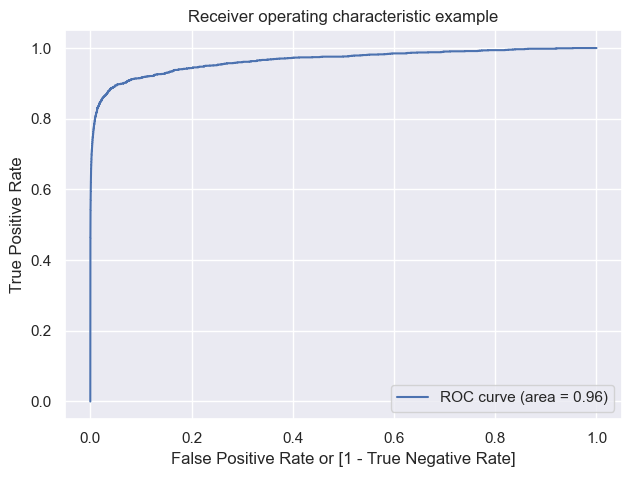


 Confussion Matrix:
 [[254773   3045]
 [   278   1239]]


In [155]:
print ('Accuracy: ', '{:.1%}'.format(accuracy_score(y_test, y_test_pred_xgb_hp)))
print ('F1 score: ', '{:.1%}'.format(f1_score(y_test, y_test_pred_xgb_hp)))
print ('Recall: ', '{:.1%}'.format(recall_score(y_test, y_test_pred_xgb_hp)))
print ('Precision: ', '{:.1%}'.format(precision_score(y_test, y_test_pred_xgb_hp)))
pred_probs_test = xgboost_best.predict_proba(X_test_pca)[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, pred_probs_test)
roc_auc = metrics.auc(fpr, tpr)
print("ROC for the test dataset:","{:.1%}".format(roc_auc))
print ('\n Classification Report:\n', classification_report(y_test, y_test_pred_xgb_hp))
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.plot(fpr,tpr,label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc=4)
plt.show()
print ('\n Confussion Matrix:\n',confusion_matrix(y_test, y_test_pred_xgb_hp))

In [156]:
confusion_xgb_hp = confusion_matrix( y_test, y_test_pred_xgb_hp)

TN = confusion_xgb_hp[0,0] # true positive 
TP = confusion_xgb_hp[1,1] # true negatives
FP = confusion_xgb_hp[0,1] # false positives
FN = confusion_xgb_hp[1,0] # false negatives


# Let's see the sensitivity of our logistic regression model
print("Sensitivity: " ,'{:.1%}'.format(TP / float(TP+FN)))

# Let us calculate specificity
print("Specificity: " ,'{:.1%}'.format(TN / float(TN+FP)))

# Calculate false postive rate - predicting churn when customer does not have churned
print("False postive rate:" ,'{:.1%}'.format(FP/ float(TN+FP)))

# positive predictive value 
print("Positive predictive value:" ,'{:.1%}'.format(TP / float(TP+FP)))

# Negative predictive value
print("Negative predictive value:" ,'{:.1%}'.format(TN / float(TN+ FN)))

Sensitivity:  81.7%
Specificity:  98.8%
False postive rate: 1.2%
Positive predictive value: 28.9%
Negative predictive value: 99.9%


Finally, let's also look at the feature importances.

## Conclusion on basis of Best Model


In [157]:
confusion_xgb_hp = confusion_matrix( y_test, y_test_pred_xgb_hp)

TN = confusion_xgb_hp[0,0] # true negatives 
TP = confusion_xgb_hp[1,1] # true positives
FP = confusion_xgb_hp[0,1] # false positives
FN = confusion_xgb_hp[1,0] # false negatives

print('True_Negatives:', TN)
print('True_Positives:', TP)
print('False_Positives:', FP)
print('False_Negatives:', FN)

True_Negatives: 254773
True_Positives: 1239
False_Positives: 3045
False_Negatives: 278


In [158]:
import joblib

# Save the model using joblib
model_filename = 'xgboost_PCA_v1.joblib'
joblib.dump(xgboost_best, model_filename)
print(f"Model saved to {model_filename}")
# Save PCA model
joblib.dump(pca, 'pca.joblib')

print("PCA model saved as 'pca.joblib'.")


Model saved to xgboost_PCA_v1.joblib
PCA model saved as 'pca.joblib'.
